Original data groups: 8638328
Cleaned data groups: 7839814


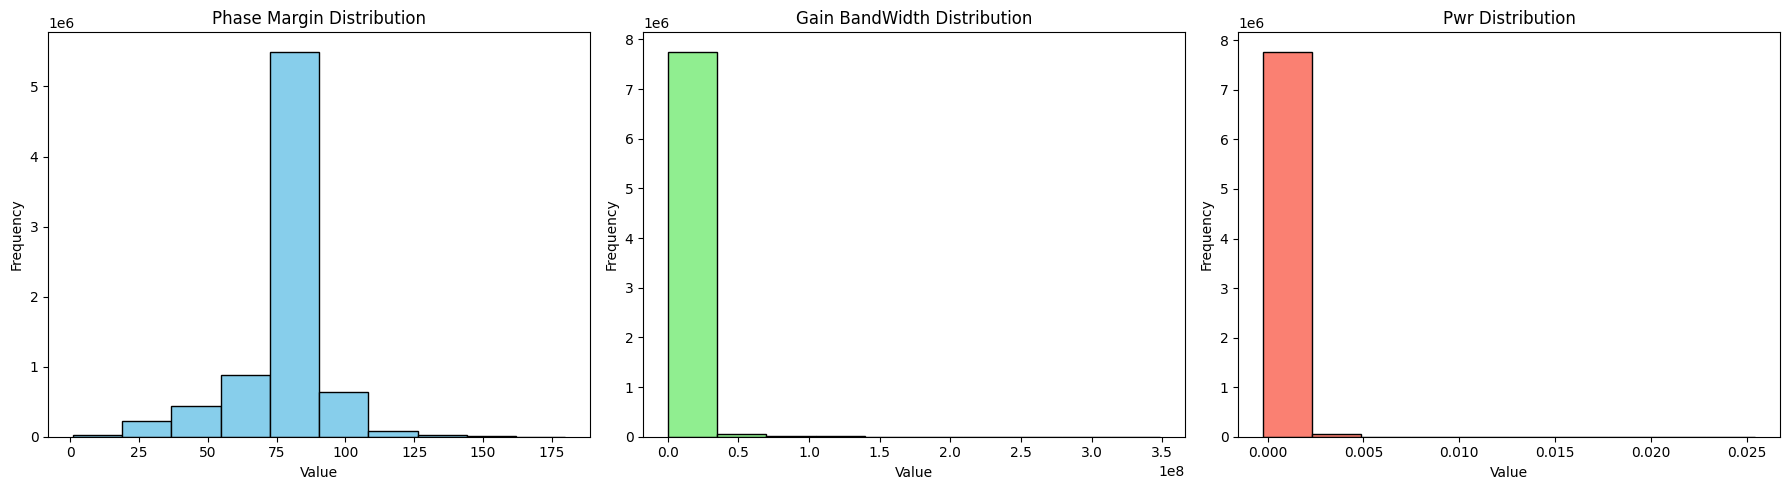

IntRangeSlider(value=(1, 179), description='Phase Margin:', max=179, min=1)

IntRangeSlider(value=(1, 348644700), description='Gain BandWidth:', max=348644700, min=1)

FloatRangeSlider(value=(-0.000247169, 0.0254544), description='Pwr:', max=0.0254544, min=-0.000247169)

interactive(children=(IntRangeSlider(value=(1, 179), description='Phase Margin:', max=179, min=1), IntRangeSli…

In [1]:
from joblib import load
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Step 1: Load data
aggregated_metrics = load("/Users/hanwu/Downloads/sum.joblib")  # Adjust the path as necessary

# Step 2: Data cleaning
df = pd.DataFrame(aggregated_metrics)
df_cleaned = df[(df['phaseMargin'] != 0) & (df['gainBandWidth'] != 0) & (df['pwr'] != 1)]

# Print the original and cleaned data counts for comparison
print(f"Original data groups: {df.shape[0]}")
print(f"Cleaned data groups: {df_cleaned.shape[0]}")

# Step 3: Display data distribution
# plt.style.use('seaborn-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df_cleaned['phaseMargin'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Phase Margin Distribution')
axes[1].hist(df_cleaned['gainBandWidth'], bins=10, color='lightgreen', edgecolor='black')
axes[1].set_title('Gain BandWidth Distribution')
axes[2].hist(df_cleaned['pwr'], bins=10, color='salmon', edgecolor='black')
axes[2].set_title('Pwr Distribution')
for ax in axes:
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 4: Interactive analysis
def update_charts(phaseMargin_range, gainBandWidth_range, pwr_range):
    filtered_df = df_cleaned[(df_cleaned['phaseMargin'] >= phaseMargin_range[0]) & (df_cleaned['phaseMargin'] <= phaseMargin_range[1]) &
                             (df_cleaned['gainBandWidth'] >= gainBandWidth_range[0]) & (df_cleaned['gainBandWidth'] <= gainBandWidth_range[1]) &
                             (df_cleaned['pwr'] >= pwr_range[0]) & (df_cleaned['pwr'] <= pwr_range[1])]
    if not filtered_df.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].hist(filtered_df['phaseMargin'], bins=10, color='skyblue', edgecolor='black')
        axes[0].set_title('Filtered Phase Margin Distribution')
        axes[1].hist(filtered_df['gainBandWidth'], bins=10, color='lightgreen', edgecolor='black')
        axes[1].set_title('Filtered Gain BandWidth Distribution')
        axes[2].hist(filtered_df['pwr'], bins=10, color='salmon', edgecolor='black')
        axes[2].set_title('Filtered Pwr Distribution')
        for ax in axes:
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print("No data available within the specified range. Please adjust the filters.")

# Define interactive widgets
phaseMargin_slider = widgets.IntRangeSlider(value=[df_cleaned['phaseMargin'].min(), df_cleaned['phaseMargin'].max()],
                                             min=df_cleaned['phaseMargin'].min(), max=df_cleaned['phaseMargin'].max(),
                                             step=1, description='Phase Margin:')
gainBandWidth_slider = widgets.IntRangeSlider(value=[df_cleaned['gainBandWidth'].min(), df_cleaned['gainBandWidth'].max()],
                                               min=df_cleaned['gainBandWidth'].min(), max=df_cleaned['gainBandWidth'].max(),
                                               step=1, description='Gain BandWidth:')
pwr_slider = widgets.FloatRangeSlider(value=[df_cleaned['pwr'].min(), df_cleaned['pwr'].max()],
                                       min=df_cleaned['pwr'].min(), max=df_cleaned['pwr'].max(),
                                       step=0.1, description='Pwr:')

# Display the widgets and set up the interaction
display(phaseMargin_slider, gainBandWidth_slider, pwr_slider)
widgets.interactive(update_charts, phaseMargin_range=phaseMargin_slider, gainBandWidth_range=gainBandWidth_slider, pwr_range=pwr_slider)
